# Avaliação dos Modelos

Nesta etapa serão comparados os modelos Logistic Regression e Random Forest utilizando métricas de classificação para identificar o modelo mais adequado para prever a qualidade dos vinhos.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [34]:
	
df = pd.read_csv('../data/raw/WineQT.csv')

df['quality_label'] = (df['quality'] >= 7).astype(int)

x = df.drop(columns=['quality', 'quality_label'])
y = df['quality_label']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

lr = LogisticRegression(random_state=42)

lr.fit(x_train_scaled, y_train)

y_pred = lr.predict(x_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print()
print(classification_report(y_test, y_pred))
print()
print(confusion_matrix(y_test, y_pred))
print()

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

print(classification_report(y_test, y_pred_rf))
print()
print(confusion_matrix(y_test, y_pred_rf))
print()
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')

Accuracy: 0.8690

              precision    recall  f1-score   support

           0       0.90      0.95      0.93       197
           1       0.55      0.34      0.42        32

    accuracy                           0.87       229
   macro avg       0.72      0.65      0.67       229
weighted avg       0.85      0.87      0.86       229


[[188   9]
 [ 21  11]]

              precision    recall  f1-score   support

           0       0.94      0.97      0.95       197
           1       0.76      0.59      0.67        32

    accuracy                           0.92       229
   macro avg       0.85      0.78      0.81       229
weighted avg       0.91      0.92      0.91       229


[[191   6]
 [ 13  19]]

Accuracy: 0.9170


In [35]:
comparison = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision Classe 1', 'Recall Classe 1', 'F1 Classe 1'],
    'Logistic Regression': [0.869, 0.55, 0.34, 0.42],
    'Random Forest': [0.917, 0.76, 0.59, 0.67]
})

comparison

,Métrica,Logistic Regression,Random Forest
0,Accuracy,0.869,0.917
1,Precision Classe 1,0.550,0.760
2,Recall Classe 1,0.340,0.590
3,F1 Classe 1,0.420,0.670


In [36]:
# Salvando a tabela.

comparison.to_csv(
    '../results/model_comparison.csv',
    index=False
)

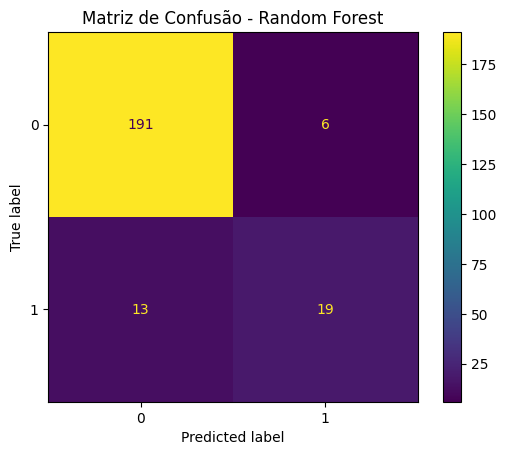

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.title('Matriz de Confusão - Random Forest')

# Salvando a matrix de confusão.
plt.savefig(
    '../results/confusion_matrix_rf.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

In [38]:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
10,alcohol,0.147784
1,volatile acidity,0.114234
2,citric acid,0.113592
9,sulphates,0.104554
7,density,0.093559
0,fixed acidity,0.071642
11,Id,0.068414
6,total sulfur dioxide,0.063946
8,pH,0.062451
3,residual sugar,0.054731


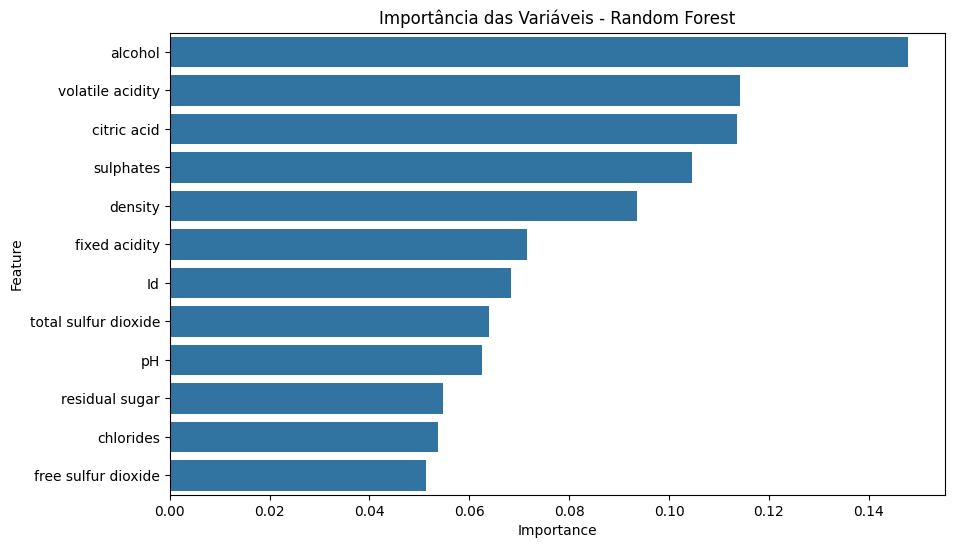

In [39]:

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Importância das Variáveis - Random Forest')

# Salvando a importância das variáveis.
 
plt.savefig(
    '../results/feature_importance_rf.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()